# E-Commerce Sales Analysis

## Project Overview

This project analyzes e-commerce sales data to identify important business trends and customer purchasing patterns.

The analysis covers:

- Product category performance
- Monthly order trends
- Regional revenue
- Payment methods
- Customer review scores
- Product price and freight comparison
- Most ordered product categories
- Order status distribution
- Delivery time performance

## Objectives

The main objectives of this project are to:

1. Understand overall sales performance.
2. Identify high-performing product categories.
3. Analyze customer purchasing patterns.
4. Identify the best-performing regions.
5. Understand preferred payment methods.
6. Analyze customer satisfaction through review scores.
7. Examine delivery performance.

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Dataset

The project uses the Brazilian E-Commerce Public Dataset by Olist.

The dataset contains information about orders, products, payments, reviews, customers, and order items.

## Project Structure

```text
Ecommerce_Sales/
│
├── charts/
├── data/
├── .venv/
└── ecommerce_sales_analysis.ipynb

In [102]:
import sys

print(sys.executable)

c:\Users\madhu\OneDrive\Desktop\IN2\.venv\Scripts\python.exe


In [103]:
import sys
print(sys.executable)

c:\Users\madhu\OneDrive\Desktop\IN2\.venv\Scripts\python.exe


In [104]:
import pandas as pd

print("Pandas version:", pd.__version__)

Pandas version: 3.0.5


In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

All libraries loaded successfully!
Pandas: 3.0.5
NumPy: 2.5.2


In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
orders = pd.read_csv("data/olist_orders_dataset.csv")

In [108]:
products = pd.read_csv("data/olist_products_dataset.csv")

In [109]:
reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")

In [110]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [111]:
orders.shape

(99441, 8)

In [112]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [113]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [114]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [115]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [116]:
products.shape

(32951, 9)

In [117]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')

In [118]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [119]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [120]:
reviews.shape

(99224, 7)

In [121]:
reviews.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')

In [122]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [123]:
orders.duplicated().sum()

np.int64(0)

In [124]:
products.duplicated().sum()

np.int64(0)

In [125]:
reviews.duplicated().sum()

np.int64(0)

In [126]:
orders["order_id"].duplicated().sum()

np.int64(0)

In [127]:
products["product_id"].duplicated().sum()

np.int64(0)

In [128]:
orders["order_purchase_timestamp"].dtype

<StringDtype(storage='python', na_value=nan)>

In [129]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [130]:
orders["order_purchase_timestamp"].dtype

dtype('<M8[us]')

In [131]:
reviews["review_creation_date"].dtype

<StringDtype(storage='python', na_value=nan)>

In [132]:
reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"]
)

In [133]:
reviews["review_creation_date"].dtype

dtype('<M8[us]')

In [134]:
reviews["review_creation_date"].dtype

dtype('<M8[us]')

In [135]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [136]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [137]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [138]:
products["product_category_name"] = products["product_category_name"].fillna("Unknown")

In [139]:
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [140]:
orders[[
    "order_id",
    "customer_id",
    "order_status",
    "order_purchase_timestamp"
]].isnull().sum()

order_id                    0
customer_id                 0
order_status                0
order_purchase_timestamp    0
dtype: int64

In [141]:
items = pd.read_csv("data/olist_order_items_dataset.csv")

In [142]:
payments = pd.read_csv("data/olist_order_payments_dataset.csv")

In [143]:
items.shape

(112650, 7)

In [144]:
payments.shape

(103886, 5)

In [145]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [146]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [147]:
items[[
    "order_id",
    "product_id",
    "price",
    "freight_value"
]].head()

,order_id,product_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,18.14


In [148]:
items[[
    "order_id",
    "product_id",
    "price"
]].isnull().sum()

order_id      0
product_id    0
price         0
dtype: int64

In [149]:
payments[[
    "order_id",
    "payment_value"
]].isnull().sum()

order_id         0
payment_value    0
dtype: int64

In [150]:
products[[
    "product_id",
    "product_category_name"
]].head()

,product_id,product_category_name
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria
1,3aa071139cb16b67ca9e5dea641aaa2f,artes
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer
3,cef67bcfe19066a932b7673e239eb23d,bebes
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas


In [151]:
sales = items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

In [152]:
sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim


In [153]:
sales.shape

(112650, 8)

In [154]:
sales.isnull().sum()

order_id                 0
order_item_id            0
product_id               0
seller_id                0
shipping_limit_date      0
price                    0
freight_value            0
product_category_name    0
dtype: int64

In [155]:
sales["product_category_name"].value_counts().head(10)

product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
Name: count, dtype: int64

In [156]:
category_revenue = (
    sales.groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
)

In [157]:
category_revenue.head(10)

product_category_name
beleza_saude              1258681.34
relogios_presentes        1205005.68
cama_mesa_banho           1036988.68
esporte_lazer              988048.97
informatica_acessorios     911954.32
moveis_decoracao           729762.49
cool_stuff                 635290.85
utilidades_domesticas      632248.66
automotivo                 592720.11
ferramentas_jardim         485256.46
Name: price, dtype: float64

In [158]:
top_category = category_revenue.idxmax()
top_revenue = category_revenue.max()

print("Top Category:", top_category)
print("Revenue:", top_revenue)

Top Category: beleza_saude
Revenue: 1258681.34


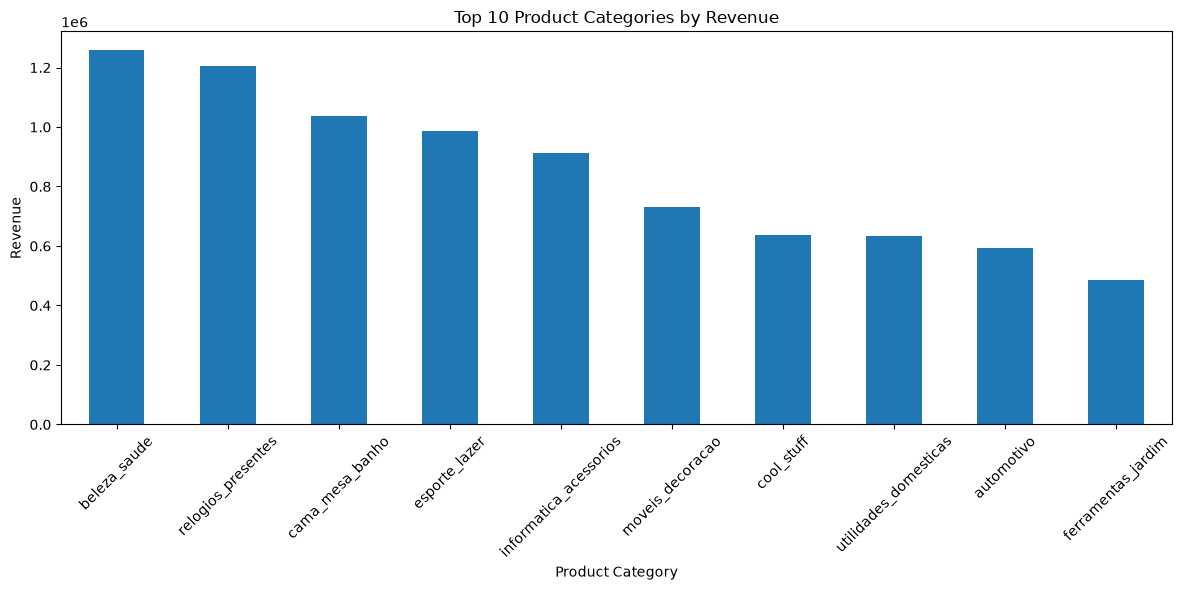

In [159]:
plt.figure(figsize=(12, 6))

category_revenue.head(10).plot(kind="bar")

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("charts/revenue_by_category.png", dpi=300, bbox_inches="tight")

plt.show()

In [160]:
orders["month"] = orders["order_purchase_timestamp"].dt.to_period("M")

In [161]:
monthly_orders = orders.groupby("month")["order_id"].nunique()

In [162]:
monthly_orders

month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64

In [163]:
peak_month = monthly_orders.idxmax()
peak_orders = monthly_orders.max()

print("Peak Month:", peak_month)
print("Number of Orders:", peak_orders)

Peak Month: 2017-11
Number of Orders: 7544


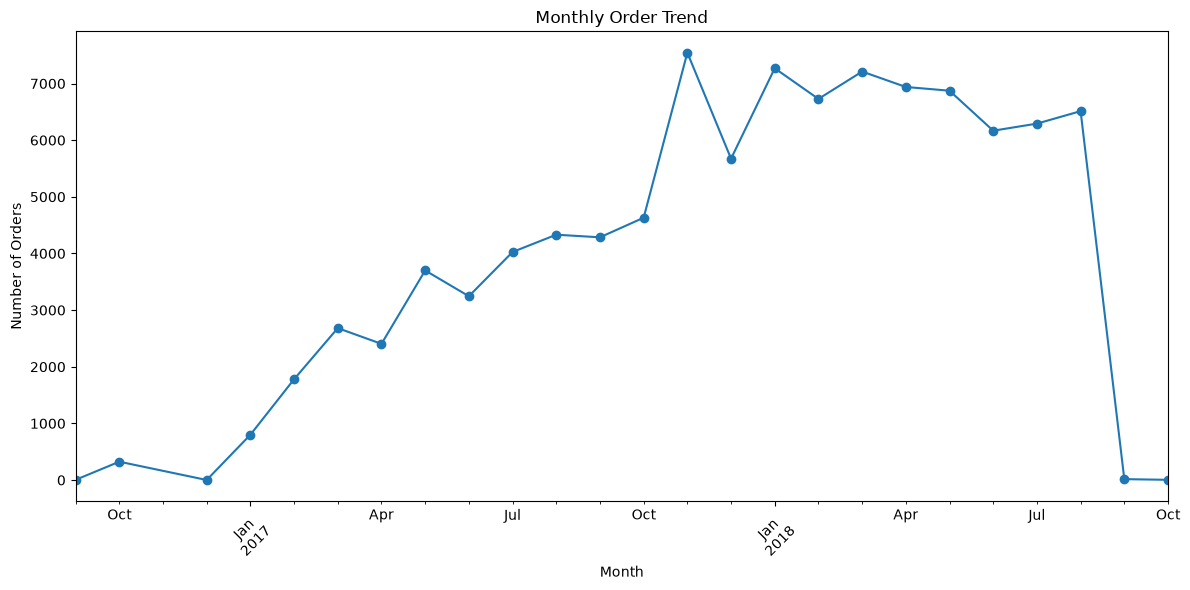

In [164]:
plt.figure(figsize=(12, 6))

monthly_orders.plot(kind="line", marker="o")

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("charts/monthly_order_trend.png", dpi=300, bbox_inches="tight")

plt.show()

In [165]:
%whos

Variable                  Type         Data/Info
------------------------------------------------
average_delivery_days     float64      12.558702304032053
average_freight           float64      19.990319928983578
average_price             float64      120.65373901464713
average_review            float64      4.08642062404257
category_orders           Series       Shape: (74,)
category_revenue          Series       Shape: (74,)
comparison                Series       Shape: (2,)
customers                 DataFrame    Shape: (99441, 5)
delivery_data             DataFrame    Shape: (96476, 10)
fastest_delivery          float64      0.5334143518518518
freight_percentage        float64      16.568338529945425
items                     DataFrame    Shape: (112650, 7)
monthly_orders            Series       Shape: (25,)
most_common_review        int64        5
np                        module       <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
order_status_counts       Series       S

In [166]:
import os

print(os.listdir("data"))

['olist_customers_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv']


In [167]:
customers = pd.read_csv("data/olist_customers_dataset.csv")

customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [168]:
customers.shape

(99441, 5)

In [169]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [170]:
sales.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name'],
      dtype='str')

In [171]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [172]:
sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim


In [173]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [174]:
sales_region = sales.merge(
    orders[["order_id", "customer_id"]],
    on="order_id",
    how="left"
)

sales_region.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,customer_id
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,3ce436f183e68e07877b285a838db11a
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,6489ae5e4333f3693df5ad4372dab6d3
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,d4eb9395c8c0431ee92fce09860c5a06
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,58dbd0b2d70206bf40e62cd34e84d795


In [175]:
sales_region = sales_region.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left"
)

sales_region.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,customer_id,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,3ce436f183e68e07877b285a838db11a,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,6489ae5e4333f3693df5ad4372dab6d3,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,d4eb9395c8c0431ee92fce09860c5a06,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,58dbd0b2d70206bf40e62cd34e84d795,SP


In [176]:
region_revenue = (
    sales_region.groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
)

region_revenue.head(10)

customer_state
SP    5202955.05
RJ    1824092.67
MG    1585308.03
RS     750304.02
PR     683083.76
SC     520553.34
BA     511349.99
DF     302603.94
GO     294591.95
ES     275037.31
Name: price, dtype: float64

In [177]:
top_region = region_revenue.idxmax()
top_region_revenue = region_revenue.max()

print("Top Region:", top_region)
print("Revenue:", round(top_region_revenue, 2))

Top Region: SP
Revenue: 5202955.05


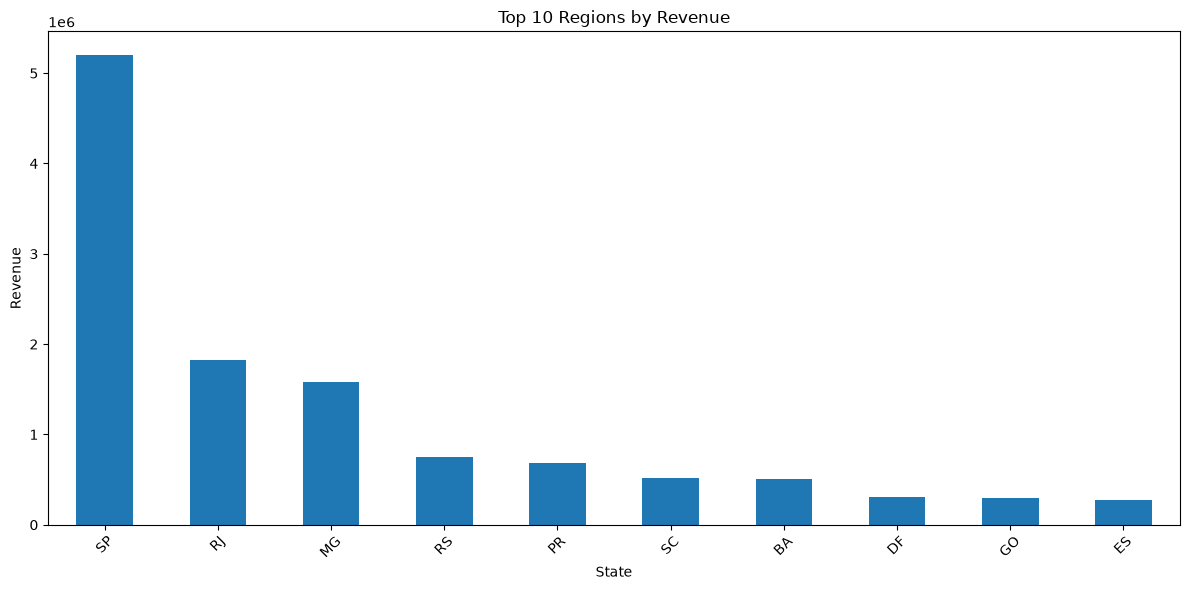

In [178]:
plt.figure(figsize=(12, 6))

region_revenue.head(10).plot(kind="bar")

plt.title("Top 10 Regions by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "charts/revenue_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [179]:
payment_counts = payments["payment_type"].value_counts()

payment_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [180]:
payment_revenue = (
    payments.groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

In [181]:
top_payment = payment_counts.idxmax()
top_payment_count = payment_counts.max()

print("Most Used Payment Method:", top_payment)
print("Number of Payments:", top_payment_count)

Most Used Payment Method: credit_card
Number of Payments: 76795


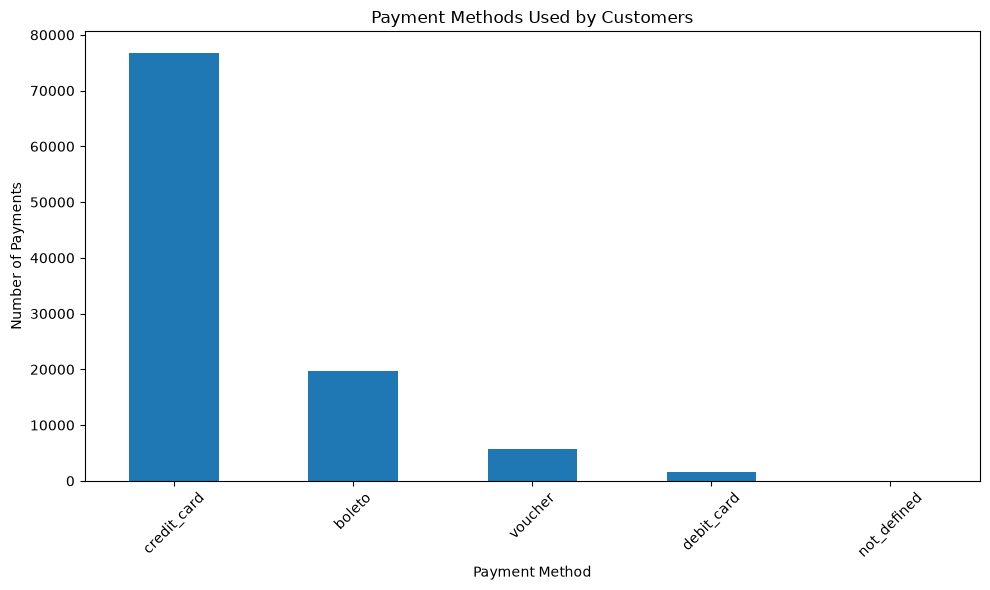

In [182]:
plt.figure(figsize=(10, 6))

payment_counts.plot(kind="bar")

plt.title("Payment Methods Used by Customers")
plt.xlabel("Payment Method")
plt.ylabel("Number of Payments")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "charts/payment_methods.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [183]:
review_counts = reviews["review_score"].value_counts().sort_index()

review_counts

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [184]:
average_review = reviews["review_score"].mean()

print("Average Review Score:", round(average_review, 2))

Average Review Score: 4.09


In [185]:
most_common_review = reviews["review_score"].mode()[0]

print("Most Common Review Score:", most_common_review)

Most Common Review Score: 5


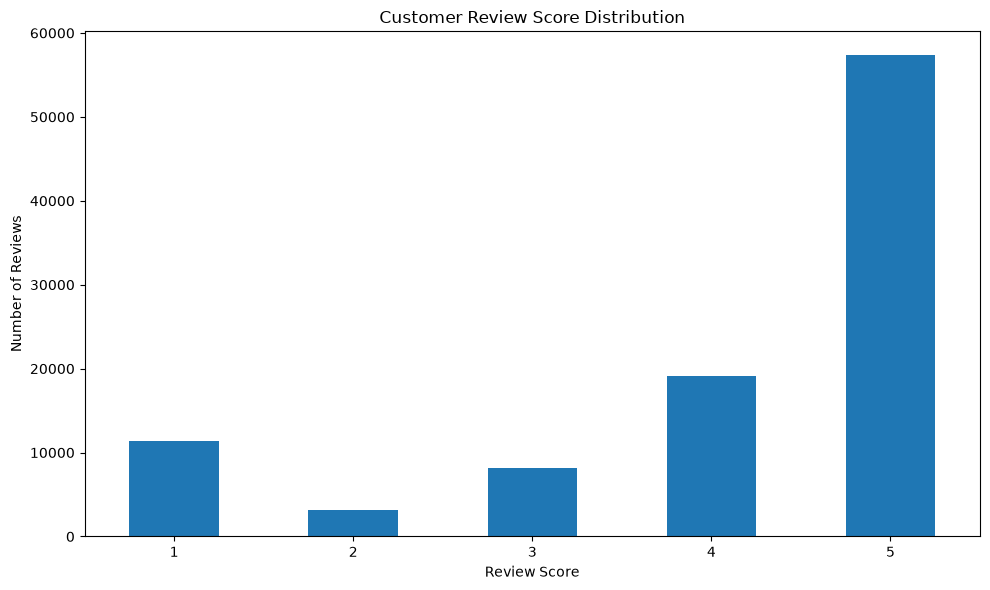

In [186]:
plt.figure(figsize=(10, 6))

review_counts.plot(kind="bar")

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "charts/review_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [187]:
total_price = sales["price"].sum()
total_freight = sales["freight_value"].sum()

print("Total Product Price:", round(total_price, 2))
print("Total Freight Value:", round(total_freight, 2))

Total Product Price: 13591643.7
Total Freight Value: 2251909.54


In [188]:
freight_percentage = (total_freight / total_price) * 100

print("Freight as % of Product Price:", round(freight_percentage, 2), "%")

Freight as % of Product Price: 16.57 %


In [189]:
average_price = sales["price"].mean()
average_freight = sales["freight_value"].mean()

print("Average Product Price:", round(average_price, 2))
print("Average Freight Value:", round(average_freight, 2))

Average Product Price: 120.65
Average Freight Value: 19.99


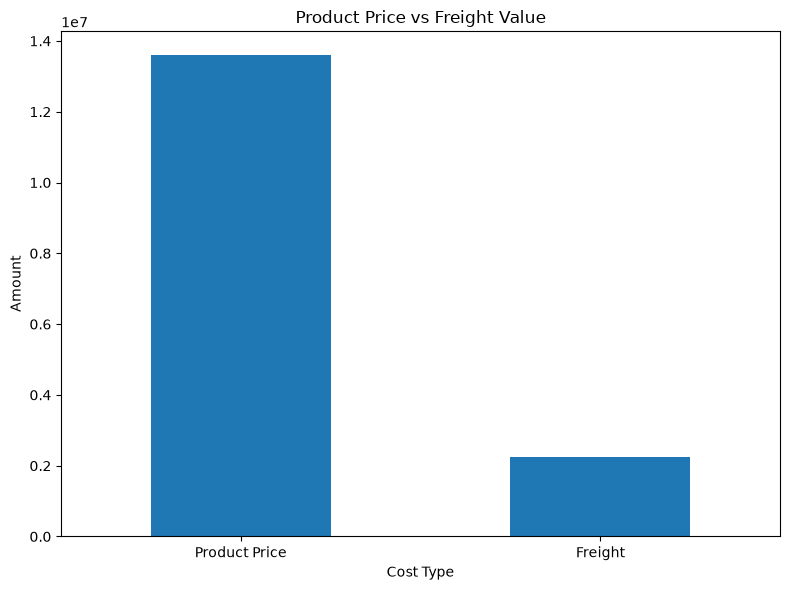

In [190]:
comparison = pd.Series({
    "Product Price": total_price,
    "Freight": total_freight
})

plt.figure(figsize=(8, 6))

comparison.plot(kind="bar")

plt.title("Product Price vs Freight Value")
plt.xlabel("Cost Type")
plt.ylabel("Amount")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "charts/price_vs_freight.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [191]:
category_orders = (
    sales["product_category_name"]
    .value_counts()
)

category_orders.head(10)

product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
Name: count, dtype: int64

In [192]:
top_ordered_category = category_orders.idxmax()
top_ordered_count = category_orders.max()

print("Most Ordered Category:", top_ordered_category)
print("Number of Items:", top_ordered_count)

Most Ordered Category: cama_mesa_banho
Number of Items: 11115


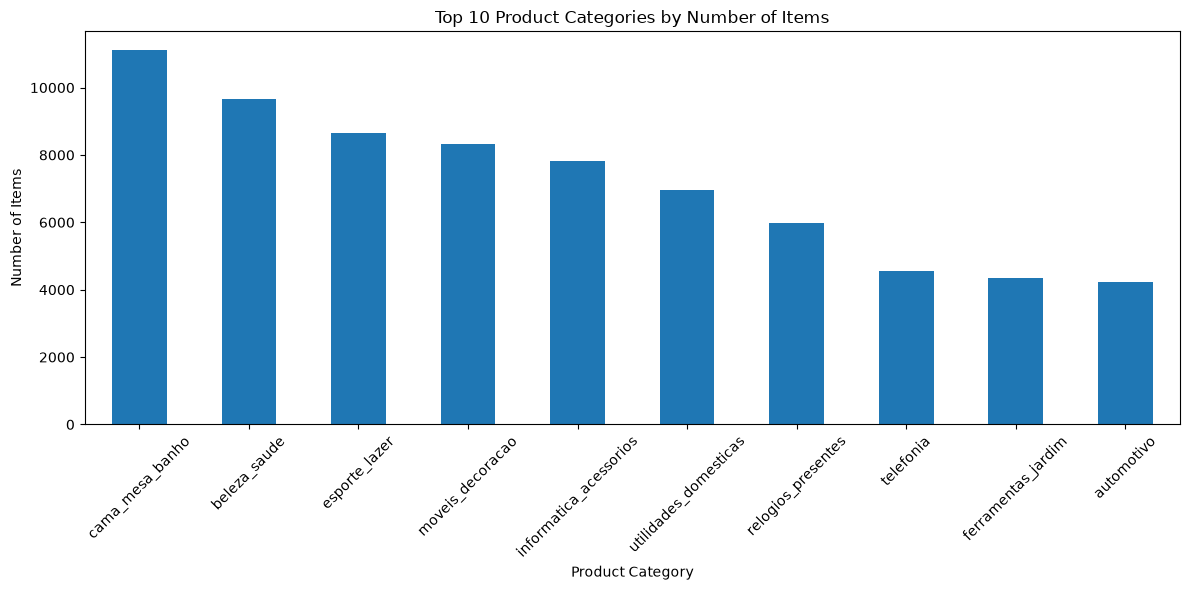

In [193]:
plt.figure(figsize=(12, 6))

category_orders.head(10).plot(kind="bar")

plt.title("Top 10 Product Categories by Number of Items")
plt.xlabel("Product Category")
plt.ylabel("Number of Items")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "charts/top_categories_by_orders.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [194]:
order_status_counts = orders["order_status"].value_counts()

order_status_counts

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [195]:
order_status_percentage = (
    orders["order_status"]
    .value_counts(normalize=True)
    * 100
)

order_status_percentage.round(2)

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

In [196]:
top_order_status = order_status_counts.idxmax()
top_order_status_count = order_status_counts.max()

print("Most Common Order Status:", top_order_status)
print("Number of Orders:", top_order_status_count)

Most Common Order Status: delivered
Number of Orders: 96478


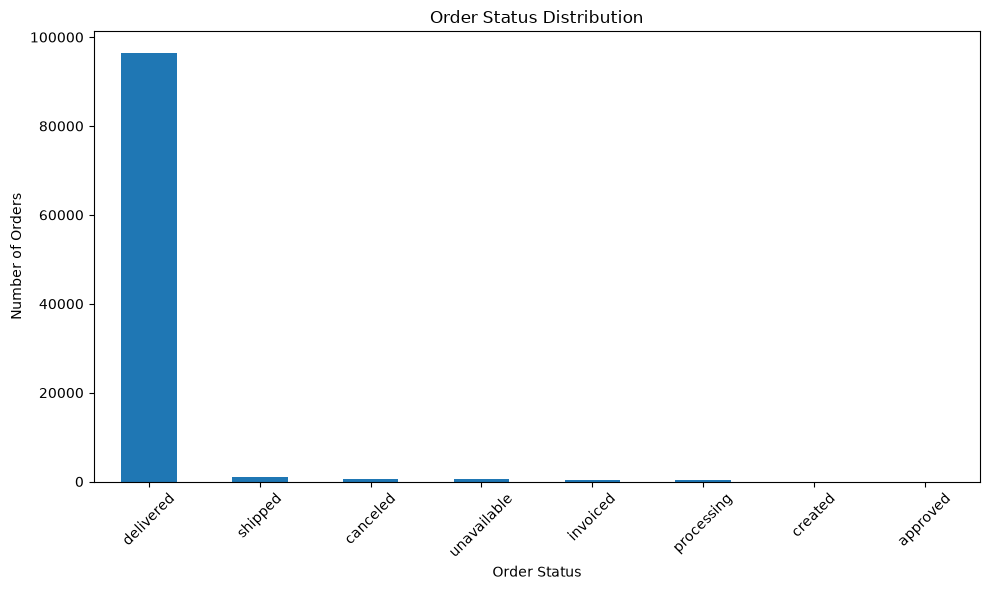

In [197]:
plt.figure(figsize=(10, 6))

order_status_counts.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "charts/order_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [198]:
delivery_data = orders.dropna(
    subset=[
        "order_purchase_timestamp",
        "order_delivered_customer_date"
    ]
).copy()

delivery_data["order_purchase_timestamp"] = pd.to_datetime(
    delivery_data["order_purchase_timestamp"]
)

delivery_data["order_delivered_customer_date"] = pd.to_datetime(
    delivery_data["order_delivered_customer_date"]
)

delivery_data["delivery_days"] = (
    delivery_data["order_delivered_customer_date"]
    - delivery_data["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

delivery_data[["order_id", "delivery_days"]].head()

,order_id,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877


In [199]:
average_delivery_days = delivery_data["delivery_days"].mean()

print(
    "Average Delivery Time:",
    round(average_delivery_days, 2),
    "days"
)

Average Delivery Time: 12.56 days


In [200]:
fastest_delivery = delivery_data["delivery_days"].min()
slowest_delivery = delivery_data["delivery_days"].max()

print("Fastest Delivery:", round(fastest_delivery, 2), "days")
print("Slowest Delivery:", round(slowest_delivery, 2), "days")

Fastest Delivery: 0.53 days
Slowest Delivery: 209.63 days


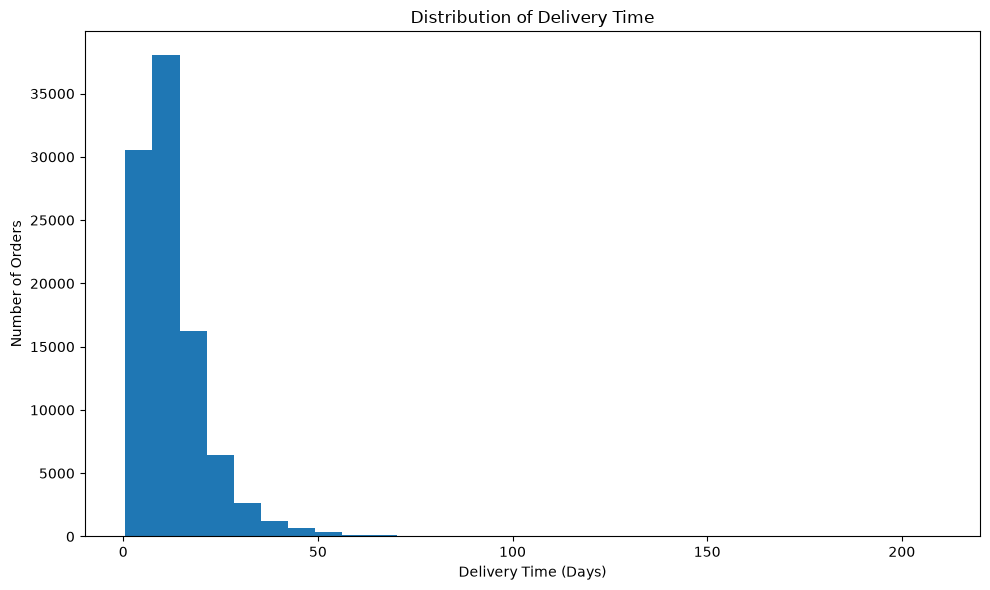

In [201]:
plt.figure(figsize=(10, 6))

delivery_data["delivery_days"].plot(
    kind="hist",
    bins=30
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    "charts/delivery_time_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [202]:
print("========== E-COMMERCE SALES ANALYSIS SUMMARY ==========")

print("\n1. TOP CATEGORY BY REVENUE")
print("Category:", top_category)
print("Revenue:", round(top_revenue, 2))

print("\n2. PEAK ORDER MONTH")
print("Month:", peak_month)
print("Orders:", peak_orders)

print("\n3. TOP REGION BY REVENUE")
print("Region:", top_region)
print("Revenue:", round(top_region_revenue, 2))

print("\n4. MOST USED PAYMENT METHOD")
print("Payment Method:", top_payment)
print("Payments:", top_payment_count)

print("\n5. CUSTOMER REVIEWS")
print("Average Review Score:", round(average_review, 2))
print("Most Common Review Score:", most_common_review)

print("\n6. FREIGHT VS PRODUCT PRICE")
print("Freight Percentage:", round(freight_percentage, 2), "%")

print("\n7. MOST ORDERED CATEGORY")
print("Category:", top_ordered_category)
print("Number of Items:", top_ordered_count)

print("\n8. MOST COMMON ORDER STATUS")
print("Status:", top_order_status)
print("Orders:", top_order_status_count)

print("\n9. DELIVERY PERFORMANCE")
print("Average Delivery Time:", round(average_delivery_days, 2), "days")

print("\n========================================================")

========== E-COMMERCE SALES ANALYSIS SUMMARY ==========

1. TOP CATEGORY BY REVENUE
Category: beleza_saude
Revenue: 1258681.34

2. PEAK ORDER MONTH
Month: 2017-11
Orders: 7544

3. TOP REGION BY REVENUE
Region: SP
Revenue: 5202955.05

4. MOST USED PAYMENT METHOD
Payment Method: credit_card
Payments: 76795

5. CUSTOMER REVIEWS
Average Review Score: 4.09
Most Common Review Score: 5

6. FREIGHT VS PRODUCT PRICE
Freight Percentage: 16.57 %

7. MOST ORDERED CATEGORY
Category: cama_mesa_banho
Number of Items: 11115

8. MOST COMMON ORDER STATUS
Status: delivered
Orders: 96478

9. DELIVERY PERFORMANCE
Average Delivery Time: 12.56 days



# Results & Business Insights

## Key Findings

### 1. Product Category Performance
The analysis identifies the highest-revenue product category and shows which categories contribute most to overall sales.

### 2. Monthly Sales Trend
Monthly order analysis helps identify periods with higher and lower customer activity. The peak month indicates the period of highest order volume.

### 3. Regional Performance
Revenue analysis across customer states identifies the strongest-performing region and helps understand the geographical distribution of sales.

### 4. Payment Preferences
The payment analysis shows which payment method is most frequently used by customers, providing insight into customer payment preferences.

### 5. Customer Satisfaction
Review score analysis provides an overview of customer satisfaction. The average review score and distribution of ratings help evaluate the overall customer experience.

### 6. Product Price and Freight
Comparing product prices with freight values helps understand the contribution of shipping costs to the overall product value.

### 7. Product Category Demand
The number of items sold by category highlights which product categories have the highest demand.

### 8. Order Fulfillment
Order status analysis shows the overall distribution of delivered, canceled, shipped, and other order statuses.

### 9. Delivery Performance
Delivery-time analysis provides an estimate of how long customers typically wait to receive their orders.

## Business Recommendations

Based on the analysis, businesses can:

- Focus marketing efforts on high-performing product categories.
- Monitor sales trends during peak and low-demand periods.
- Strengthen operations in high-revenue regions.
- Continue supporting popular payment methods.
- Improve customer service based on review patterns.
- Monitor freight costs to maintain competitive pricing.
- Optimize inventory for high-demand categories.
- Improve delivery processes to reduce delivery times.


# Conclusion

This project analyzed e-commerce sales data using Python and identified important patterns in sales, customers, products, payments, reviews, regions, and delivery performance.

The analysis demonstrates how exploratory data analysis can be used to transform raw e-commerce data into meaningful business insights that can support better decision-making.